## ARIMAX

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import pickle

In [2]:
# Load merged data: prioritize CSV 'merged_data_final.csv', fallback to pickle or synthetic data for testing
import os
csv_path = '../data/processed/merged_data_final.csv'
data = pd.read_csv(csv_path, parse_dates=['datetime'])

# Ensure datetime is set as the time index
if 'datetime' in data.columns:
    data['datetime'] = pd.to_datetime(data['datetime'])
    data.set_index('datetime', inplace=True)

# Use 'close' as the target series
close_prices = data['close']

# Prepare exogenous variables. If missing, print warning and fill with 0 to ensure dimension consistency
exog_cols = ['roe_lag45d','ps_lag45d','de_ratio_lag45d','CAPEI_lag45d','bm_lag45d', 'avg_sentiment_neg_lag1d', 'avg_sentiment_neu_lag1d', 'avg_sentiment_pos_lag1d']
missing = [c for c in exog_cols if c not in data.columns]
if missing:
    print(f'Warning: The following exogenous variable columns are missing in the data and will be filled with 0: {missing}')
    for c in missing:
        data[c] = 0.0

# Construct exog DataFrame, ensuring correct order and alignment with close_prices
exog = data[exog_cols].astype(float)
# Simple check: length should match
assert len(exog) == len(close_prices), 'Exogenous variable length does not match target series length'

In [3]:
# Automatically select ARIMAX (with exogenous variables) parameters: use exog as the exogenous variable
# Note: the exogenous parameter name in auto_arima is 'exogenous'
model = auto_arima(close_prices, exogenous=exog, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=19904.558, Time=16.66 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=19971.055, Time=4.75 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=19915.095, Time=3.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=19915.165, Time=2.36 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=19971.514, Time=2.65 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=19912.288, Time=8.91 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=19919.078, Time=7.89 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=19907.878, Time=17.90 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=19904.938, Time=40.24 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=19917.024, Time=10.99 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=19905.320, Time=12.55 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=19911.987, Time=12.26 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=19906.373, Time=54.81 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=19905.164, Time=4.39 sec

Best model:


==================== Close Price Stationarity Test Report ====================
ADF Statistic: -1.6411
p-value:       0.4617
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).


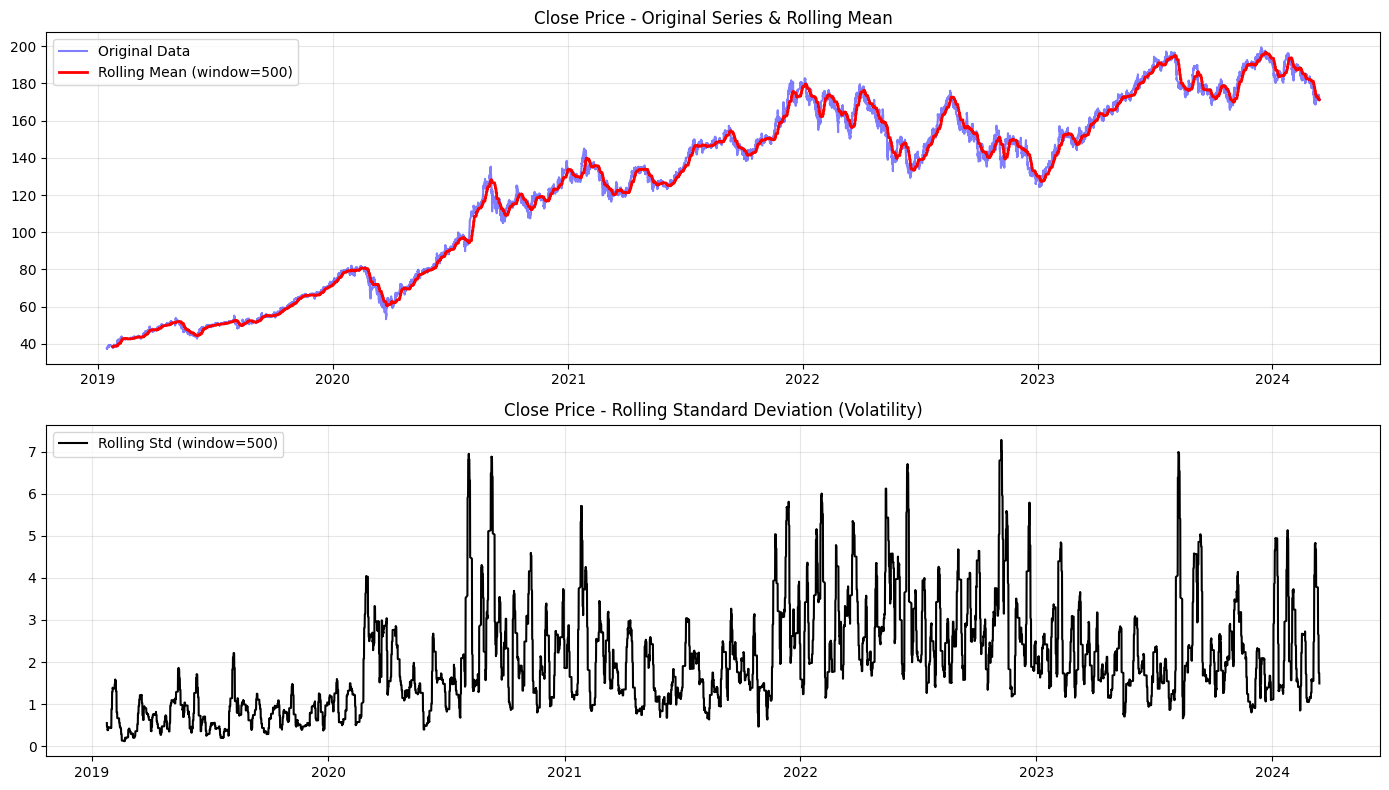


Original data detected as non-stationary, testing 1st Order Differenced data...

==================== 1st Order Differenced Close Price Stationarity Test Report ====================
ADF Statistic: -91.5038
p-value:       0.0000
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value < 0.05, the data is [STATIONARY].


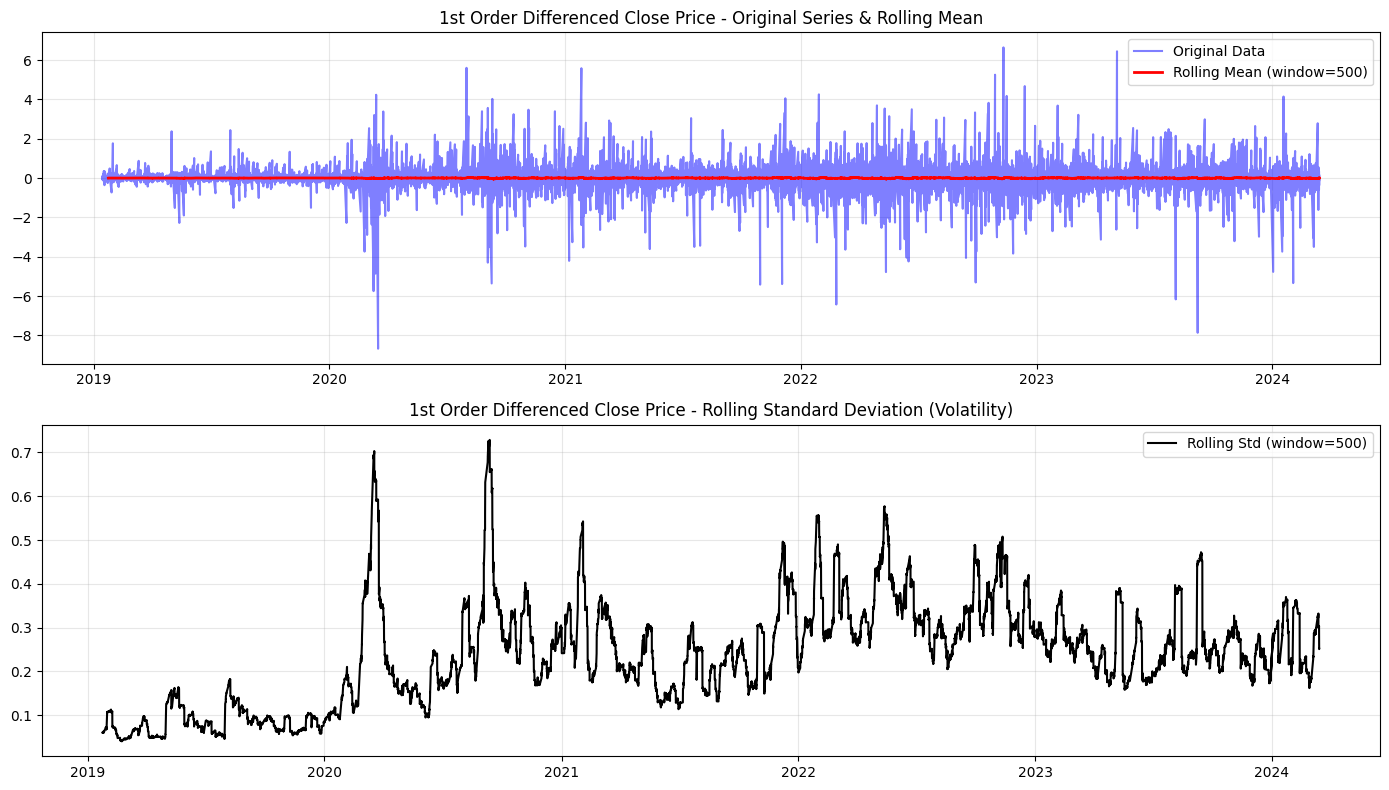


==================== Exogenous Variables Stationarity Overview ====================
Variable             | p-value    | Stationary?
---------------------------------------------
roe_lag45d           | 0.9038     | No
ps_lag45d            | 0.4260     | No
de_ratio_lag45d      | 0.6708     | No
CAPEI_lag45d         | 0.4149     | No
bm_lag45d            | 0.6805     | No
avg_sentiment_neg_lag1d | 0.0000     | Yes
avg_sentiment_neu_lag1d | 0.0000     | Yes
avg_sentiment_pos_lag1d | 0.0000     | Yes


In [4]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity_and_plot(series, title="Time Series", window_size=1000):
    """
    Performs the Augmented Dickey-Fuller (ADF) test and plots the stationarity analysis (Original Data vs Rolling Mean/Std Dev)
    """
    print(f"\n{'='*20} {title} Stationarity Test Report {'='*20}")
    
    # 1. ADF Statistical Test
    # Note: ADF cannot handle NaN, they must be removed
    clean_series = series.dropna()
    result = adfuller(clean_series)
    
    p_value = result[1]
    is_stationary = p_value < 0.05
    
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if is_stationary:
        print(f"Conclusion: p-value < 0.05, the data is [STATIONARY].")
    else:
        print(f"Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).")

    # 2. Plotting Analysis
    plt.figure(figsize=(14, 8))
    
    # Top plot: Original data + Rolling Mean
    plt.subplot(2, 1, 1)
    plt.plot(series, label='Original Data', color='blue', alpha=0.5)
    # Calculate Rolling Mean and Rolling Standard Deviation
    rolmean = series.rolling(window=window_size).mean()
    rolstd = series.rolling(window=window_size).std()
    
    plt.plot(rolmean, label=f'Rolling Mean (window={window_size})', color='red', linewidth=2)
    plt.legend(loc='best')
    plt.title(f'{title} - Original Series & Rolling Mean')
    plt.grid(True, alpha=0.3)
    
    # Bottom plot: Rolling Standard Deviation (to check if volatility is stable)
    plt.subplot(2, 1, 2)
    plt.plot(rolstd, label=f'Rolling Std (window={window_size})', color='black')
    plt.legend(loc='best')
    plt.title(f'{title} - Rolling Standard Deviation (Volatility)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return is_stationary

# ==========================================
# Execution Code
# ==========================================

# 1. Test the Target Variable (Close Price)
# Original prices are typically non-stationary
is_close_stationary = check_stationarity_and_plot(close_prices, "Close Price", window_size=500)

# 2. If non-stationary, test the First Difference data
# This is what d=1 does in auto_arima
if not is_close_stationary:
    print("\nOriginal data detected as non-stationary, testing 1st Order Differenced data...")
    diff_series = close_prices.diff()
    check_stationarity_and_plot(diff_series, "1st Order Differenced Close Price", window_size=500)

# 3. (Optional) Quick check for Exogenous Variables
# ARIMAX preferably requires exogenous variables to be stationary. Print only text results to avoid excessive plots.
print(f"\n{'='*20} Exogenous Variables Stationarity Overview {'='*20}")
print(f"{'Variable':<20} | {'p-value':<10} | {'Stationary?'}")
print("-" * 45)

for col in exog_cols:
    clean_exog = data[col].dropna()
    res = adfuller(clean_exog)
    p_val = res[1]
    status = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<20} | {p_val:.4f}     | {status}")

In [5]:
# Fit the ARIMAX model using the selected parameters (including exogenous variables exog)
order = model.order
# Pass exog into the model to construct ARIMAX
arima_model = ARIMA(close_prices, order=order, exog=exog)
arima_result = arima_model.fit()
print(arima_result.summary())

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               101860
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9783.990
Date:                Sat, 29 Nov 2025   AIC                          19593.980
Time:                        05:27:16   BIC                          19717.887
Sample:                             0   HQIC                         19631.551
                             - 101860                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
roe_lag45d                 -4.3711      0.182    -23.957      0.000      -4.729      -4.014
ps_lag45d                  -0.7105      0.040    -17.695      0.000      -0.789      -0.632


In [6]:
# Forecast future values (e.g., for the next 100 periods), with simple handling for exogenous variables: repeat the most recently observed exog values
forecast_steps = 100
# Create a time index for the future forecast (assuming 5-minute data interval)
last_datetime = close_prices.index[-1]
forecast_index = pd.date_range(start=last_datetime, periods=forecast_steps+1, freq='5min')[1:]  # Assuming 5-minute data

# Construct future exogenous variables: here we make a simple assumption—repeat the last observed exog value for 'forecast_steps' times
# A more robust approach would be to build separate forecasts for each exogenous variable, but that is outside the current modification scope
future_exog = pd.DataFrame([exog.iloc[-1].values] * forecast_steps, columns=exog.columns, index=forecast_index)

# Use arima_result.forecast by passing the future exog (for ARIMAX)
forecast = arima_result.forecast(steps=forecast_steps, exog=future_exog)

# For predictions on the test set (to compare with actual values), a corresponding exog slice must be provided
test_size = len(close_prices) - int(len(close_prices) * 0.8)
start_idx = len(close_prices) - test_size
end_idx = len(close_prices) - 1
exog_test_slice = exog.iloc[start_idx: end_idx + 1]
arima_test_forecast = arima_result.predict(start=start_idx, end=end_idx, exog=exog_test_slice)

# Combine actual values and forecasts for plotting
actual_series = close_prices
forecast_series = pd.Series(forecast.values, index=forecast_index)
arima_test_series = pd.Series(arima_test_forecast, index=close_prices.index[-test_size:])

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
# Evaluation Metrics (MSE, MAE, RMSE)

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Extract true test values and predicted test values
y_true = actual_series.iloc[start_idx: end_idx + 1]
y_pred = arima_test_series

# Ensure alignment (important for time series)
y_true, y_pred = y_true.align(y_pred, join='inner')

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("\n==== Model Evaluation Metrics (Test Set) ====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


==== Model Evaluation Metrics (Test Set) ====
MSE : 0.0670
MAE : 0.1524
RMSE: 0.2588


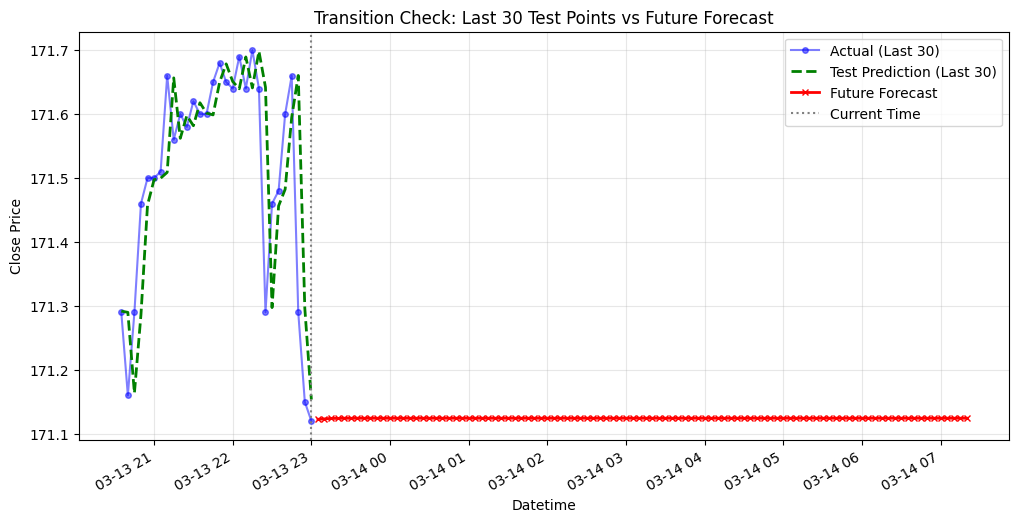

In [8]:
# Set the size of the focused window
window_size = 30

plt.figure(figsize=(12, 6))

# 1. Plot the last 30 actual values (as the baseline reference)
# Use .tail(window_size) to automatically get the last 30 points
plt.plot(close_prices.index[-window_size:], 
         close_prices.tail(window_size), 
         label='Actual (Last 30)', color='blue', marker='o', markersize=4, alpha=0.5)

# 2. Plot the last 30 test set predictions (to see model performance at the end of known data)
# Assuming arima_test_series is long enough, take the last 30 points
if len(arima_test_series) >= window_size:
    plt.plot(arima_test_series.index[-window_size:], 
             arima_test_series.tail(window_size), 
             label='Test Prediction (Last 30)', color='green', linestyle='--', linewidth=2)

# 3. Plot the future forecast (all points)
plt.plot(forecast_series.index, 
         forecast_series, 
         label='Future Forecast', color='red', marker='x', markersize=4, linewidth=2)

# Add a vertical line to mark the 'current time' boundary
last_date = close_prices.index[-1]
plt.axvline(x=last_date, color='gray', linestyle=':', label='Current Time')

plt.title(f'Transition Check: Last {window_size} Test Points vs Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Automatically rotate date labels to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

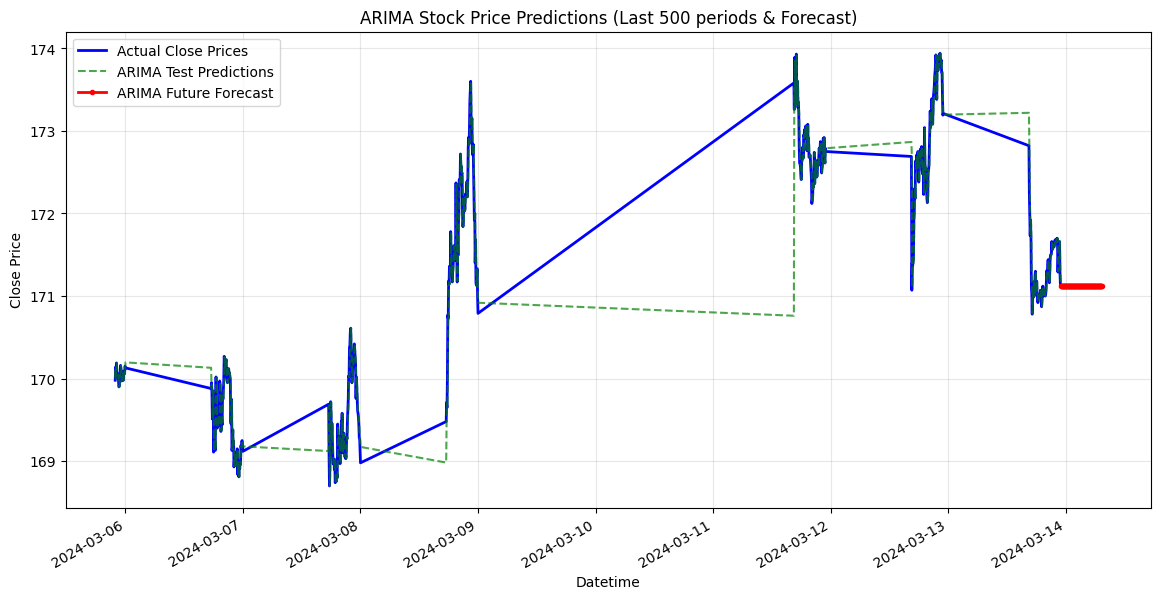

In [9]:
# Set the display window size (e.g., only show the last 500 points + future forecast)
zoom_window = 500 

plt.figure(figsize=(14, 7))

# 1. Plot historical data (only take the last zoom_window points)
# Use .tail() to slice the end
plt.plot(close_prices.index[-zoom_window:], 
         close_prices.tail(zoom_window), 
         label='Actual Close Prices', color='blue', linewidth=2)

# 2. Plot test set predictions (if there is overlap, only take the most recent)
# Ensure the index is within the zoom_window range before displaying
subset_test = arima_test_series[arima_test_series.index >= close_prices.index[-zoom_window]]
if not subset_test.empty:
    plt.plot(subset_test.index, subset_test, 
             label='ARIMA Test Predictions', color='green', linestyle='--', alpha=0.7)

# 3. Plot future forecast (this is the part you just created, plot all points)
plt.plot(forecast_series.index, forecast_series, 
         label='ARIMA Future Forecast', color='red', marker='.', linestyle='-', linewidth=2)

plt.title(f'ARIMA Stock Price Predictions (Last {zoom_window} periods & Forecast)')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Optimize X-axis time display to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

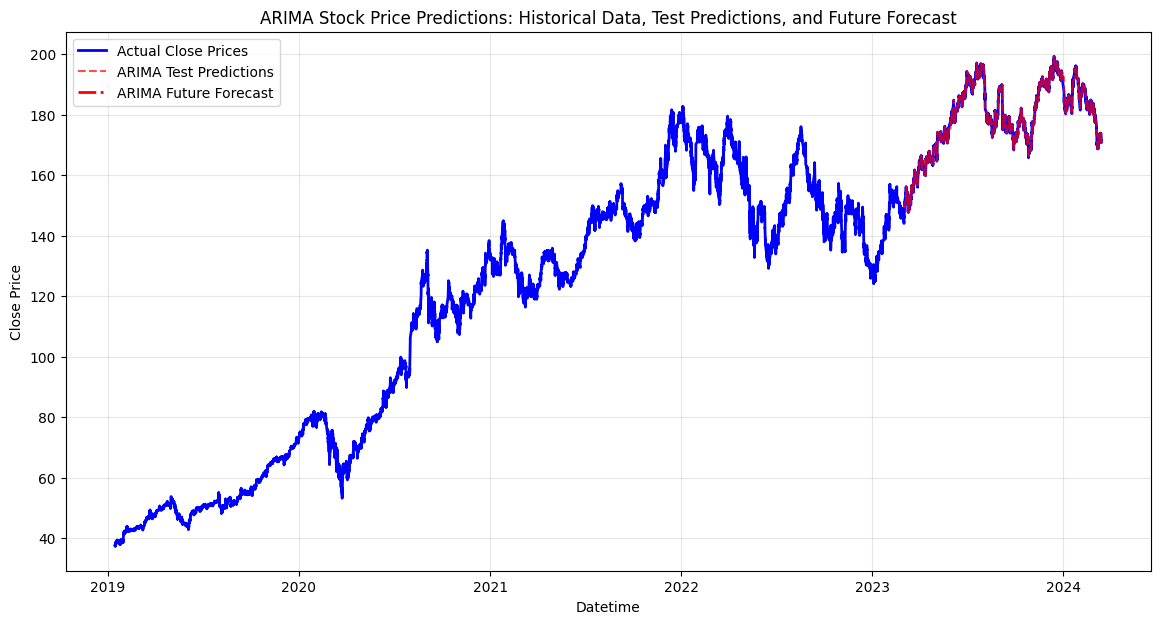

In [10]:
# Plot ARIMA predictions: historical data, test predictions, and future forecast
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(arima_test_series.index, arima_test_series, label='ARIMA Test Predictions', color='red', linestyle='--', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Future Forecast', color='red', linestyle='-.', linewidth=2)
plt.title('ARIMA Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM

In [11]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from sklearn.preprocessing import StandardScaler
from src.train import create_sequences, train_lstm, predict_lstm
from src.model import LSTMModel
import torch
from torch.utils.data import DataLoader, TensorDataset



# Prepare data for LSTM
raw_train_size = int(len(close_prices) * 0.8)
train_data_raw = close_prices.iloc[:raw_train_size].values.reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(train_data_raw) 

scaled_data = scaler.transform(close_prices.values.reshape(-1, 1))

seq_length = 60  # Use 60 time steps (5 hours of 5-min data)
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_split_idx = raw_train_size - seq_length

if train_split_idx < 0:
    raise ValueError("Not enough data to create sequences of the specified length.")

X_train, X_test = X[:train_split_idx], X[train_split_idx:]
y_train, y_test = y[:train_split_idx], y[train_split_idx:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data prepared. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Scaler used: StandardScaler (Mean: {scaler.mean_[0]:.2f}, Scale: {scaler.scale_[0]:.2f})")


model = LSTMModel()
model = train_lstm(model, train_loader, num_epochs=50, lr=0.001)
forecast_steps = 100

test_predictions, future_predictions = predict_lstm(
    model, 
    X_test, 
    scaled_data, 
    scaler, 
    seq_length, 
    forecast_steps
)

# Create forecast series for LSTM
last_timestamp = close_prices.index[-1]
lstm_forecast_index = pd.date_range(start=last_timestamp, periods=forecast_steps+1, freq='5min')[1:]
lstm_forecast_series = pd.Series(future_predictions.flatten(), index=lstm_forecast_index)

lstm_test_index = close_prices.index[raw_train_size : raw_train_size + len(test_predictions)]
lstm_test_series = pd.Series(test_predictions.flatten(), index=lstm_test_index)

print("Predictions and forecasting completed.")

Data prepared. Train shape: torch.Size([81428, 60, 1]), Test shape: torch.Size([20372, 60, 1])
Scaler used: StandardScaler (Mean: 112.77, Scale: 42.50)
Starting LSTM training...
LSTM Epoch [10/50], Loss: 0.00015991
LSTM Epoch [20/50], Loss: 0.00013893
LSTM Epoch [30/50], Loss: 0.00036516
LSTM Epoch [40/50], Loss: 0.00016176
LSTM Epoch [50/50], Loss: 0.00009686
LSTM Training completed.
Predictions and forecasting completed.


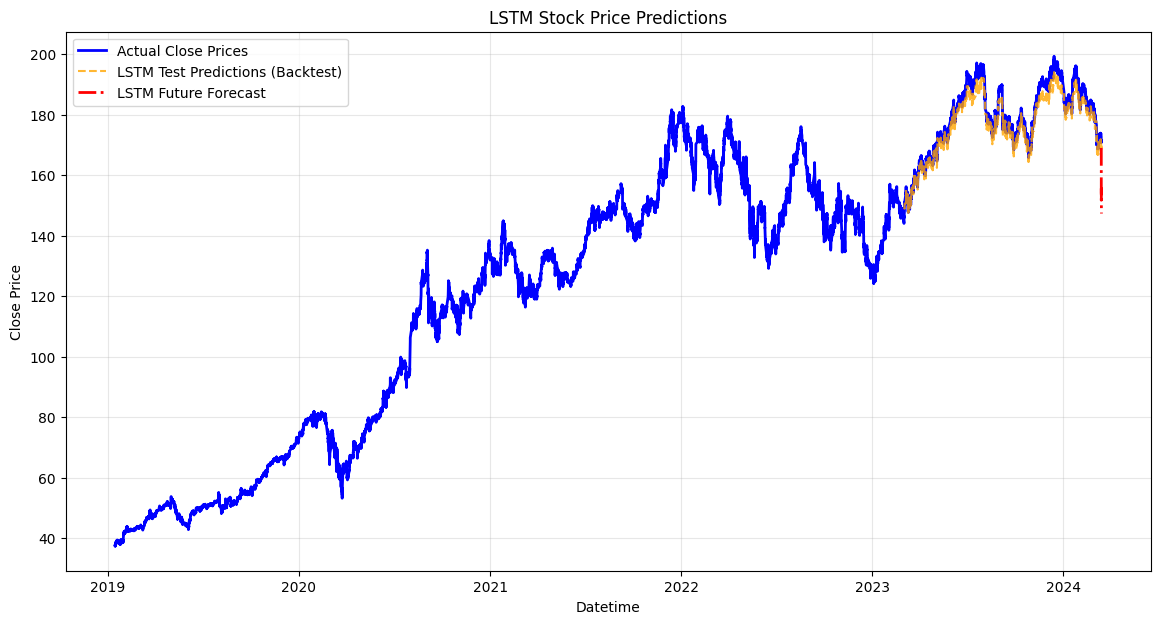

In [12]:
# Plot LSTM predictions
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index, lstm_test_series, label='LSTM Test Predictions (Backtest)', color='orange', linestyle='--', alpha=0.8)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Future Forecast', color='red', linestyle='-.', linewidth=2)

plt.title('LSTM Stock Price Predictions')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

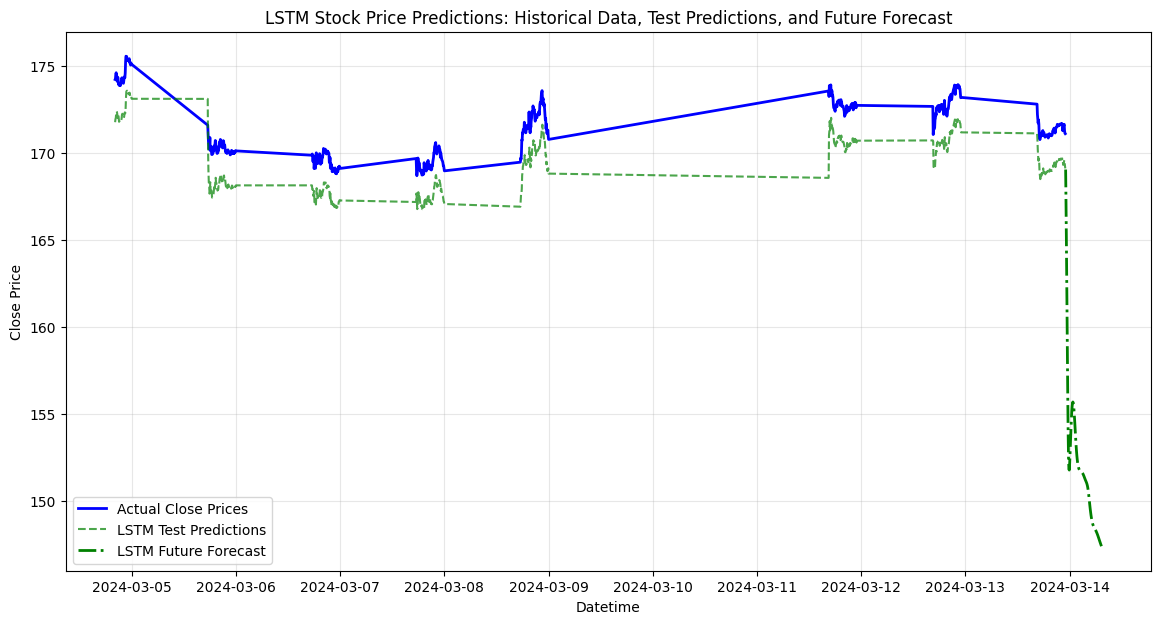

In [13]:
# Plot LSTM predictions: historical data, test predictions, and future forecast
last_n = 600
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index[-last_n:], close_prices.iloc[-last_n:], label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index[-last_n:], lstm_test_series[-last_n:], label='LSTM Test Predictions', color='green', linestyle='--', alpha=0.7)
plt.plot(lstm_forecast_series.index[-last_n:], lstm_forecast_series[-last_n:], label='LSTM Future Forecast', color='green', linestyle='-.', linewidth=2)
plt.title('LSTM Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM-MLP

In [14]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import torch
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from src.model import LSTMModel, MLPModel
from src.train import train_lstm, train_mlp, create_sequences, run_hybrid_forecast
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
# Preprocessing (LSTM)
# Split sizes
raw_train_size = int(len(close_prices) * 0.8)

# Scale Close Prices (Target)
scaler_price = StandardScaler()
train_data_raw = close_prices.iloc[:raw_train_size].values.reshape(-1, 1)
scaler_price.fit(train_data_raw)
scaled_close = scaler_price.transform(close_prices.values.reshape(-1, 1))

# Scale Exogenous Variables (Important for MLP)
scaler_exog = StandardScaler()
train_exog_raw = exog.iloc[:raw_train_size].values
scaler_exog.fit(train_exog_raw)
scaled_exog = scaler_exog.transform(exog.values)

# Create LSTM Sequences
seq_length = 60
X_lstm, y_lstm = create_sequences(scaled_close, seq_length)

# Prepare LSTM Train Data
train_split_idx = raw_train_size - seq_length
if train_split_idx < 0: raise ValueError("Not enough data.")

X_train_lstm = torch.tensor(X_lstm[:train_split_idx], dtype=torch.float32)
y_train_lstm = torch.tensor(y_lstm[:train_split_idx], dtype=torch.float32)

lstm_loader = DataLoader(TensorDataset(X_train_lstm, y_train_lstm), batch_size=32, shuffle=True)

In [16]:
# Train LSTM
lstm_model = LSTMModel(dropout=0.2) 
lstm_model = train_lstm(lstm_model, lstm_loader, num_epochs=20, lr=0.001)

Starting LSTM training...
LSTM Epoch [10/20], Loss: 0.00011899
LSTM Epoch [20/20], Loss: 0.00040555
LSTM Training completed.


In [17]:
# We need to run the LSTM on the existing data to get its "base predictions"
# These base predictions + exog vars will be the input to the MLP.

lstm_model.eval()
with torch.no_grad():
    # Get LSTM predictions for the ENTIRE dataset available for creating sequences
    # Input X_lstm covers data from index 0 to N-1
    # Prediction corresponds to index seq_length to N
    all_lstm_inputs = torch.tensor(X_lstm, dtype=torch.float32)
    lstm_outputs = lstm_model(all_lstm_inputs) # Shape: [N_samples, 1]

# Align Exogenous Features with LSTM Outputs
# X_lstm[i] uses data from i to i+seq_length. The label is at i+seq_length.
# So the Exog data should also be taken from i+seq_length.
aligned_exog = scaled_exog[seq_length:] 

# Truncate to match lengths (just in case)
min_len = min(len(lstm_outputs), len(aligned_exog))
lstm_outputs = lstm_outputs[:min_len]
aligned_exog_tensor = torch.tensor(aligned_exog[:min_len], dtype=torch.float32)

# Concatenate [LSTM_Pred, Exog_Vars]
X_mlp = torch.cat((lstm_outputs, aligned_exog_tensor), dim=1) 
# Target for MLP is the actual scaled close price at that time
y_mlp = torch.tensor(scaled_close[seq_length:seq_length+min_len], dtype=torch.float32)

# Split MLP Data (Train/Test)
# We use the same split index logic, but adjusted for the sequence offset
mlp_train_size = train_split_idx 

# Train Set
X_train_mlp = X_mlp[:mlp_train_size]
y_train_mlp = y_mlp[:mlp_train_size]

# Test Set (For Evaluation)
X_test_mlp = X_mlp[mlp_train_size:]
y_test_mlp = y_mlp[mlp_train_size:]

mlp_loader = DataLoader(TensorDataset(X_train_mlp, y_train_mlp), batch_size=32, shuffle=True)

print(f"MLP Data Prepared. Input Features: {X_mlp.shape[1]} (1 LSTM + {aligned_exog.shape[1]} Exog)")
print(f"MLP Train Size: {len(X_train_mlp)}, MLP Test Size: {len(X_test_mlp)}")

MLP Data Prepared. Input Features: 9 (1 LSTM + 8 Exog)
MLP Train Size: 81428, MLP Test Size: 20372


In [18]:
#Train MLP
# Input size = 1 (LSTM pred) + Number of Exog columns
mlp_input_size = 1 + exog.shape[1]
mlp_model = MLPModel(input_size=mlp_input_size, hidden_size1=64, hidden_size2=32)

mlp_model = train_mlp(mlp_model, mlp_loader, num_epochs=20, lr=0.001)

Starting MLP training...
MLP Epoch [10/20], Loss: 0.00003552
MLP Epoch [20/20], Loss: 0.00002344
MLP Training completed.


In [19]:
# Model Evaluation on Test Set
mlp_model.eval()
with torch.no_grad():
    # Predict on the MLP Test Set
    test_preds_scaled = mlp_model(X_test_mlp).numpy()

# Inverse transform to get actual prices (Un-scaled)
test_preds_actual = scaler_price.inverse_transform(test_preds_scaled)
y_test_actual = scaler_price.inverse_transform(y_test_mlp.reshape(-1, 1).numpy())

# Calculate Metrics
mse = mean_squared_error(y_test_actual, test_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_preds_actual)

print("\n==== Model Evaluation Metrics (Test Set) ====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



==== Model Evaluation Metrics (Test Set) ====
MSE : 3.9380
MAE : 1.2760
RMSE: 1.9844


In [20]:
# Hybrid Forecasting (Future 100 Steps)
forecast_steps = 100

# Injecting noise to prevent "straight line" forecast
hybrid_predictions = run_hybrid_forecast(
    lstm_model,
    mlp_model,
    scaled_close,
    scaled_exog,
    scaler_price,
    scaler_exog,
    seq_length,
    forecast_steps,
    noise_level=0.01  # Adjust this to control volatility (0.01 - 0.1 is usually good)
)

# Create Pandas Series for plotting
last_timestamp = close_prices.index[-1]
forecast_index = pd.date_range(start=last_timestamp, periods=forecast_steps+1, freq='5min')[1:]
forecast_series = pd.Series(hybrid_predictions.flatten(), index=forecast_index)

print("Hybrid Forecasting completed.")
print(forecast_series)

Hybrid Forecasting completed.
2024-03-13 23:05:00    171.291636
2024-03-13 23:10:00    171.037748
2024-03-13 23:15:00    171.316885
2024-03-13 23:20:00    171.468568
2024-03-13 23:25:00    171.927348
                          ...    
2024-03-14 07:00:00    172.919832
2024-03-14 07:05:00    173.097691
2024-03-14 07:10:00    173.009704
2024-03-14 07:15:00    173.025817
2024-03-14 07:20:00    173.189017
Freq: 5min, Length: 100, dtype: float64


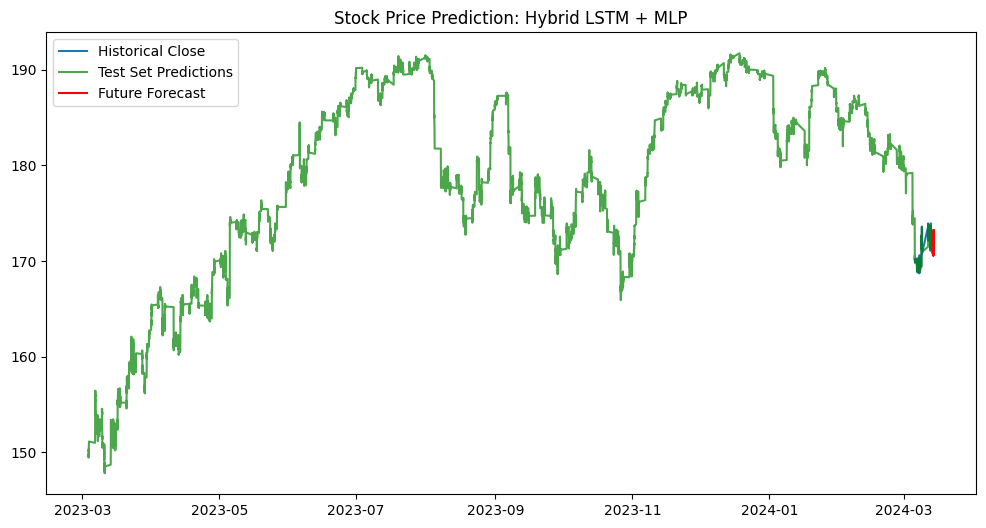

In [21]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(close_prices.index[-500:], close_prices.values[-500:], label='Historical Close')
# Plot test set predictions for visual validation
test_index_plot = close_prices.index[seq_length + mlp_train_size : seq_length + mlp_train_size + len(test_preds_actual)]
if len(test_index_plot) == len(test_preds_actual):
     plt.plot(test_index_plot, test_preds_actual, label='Test Set Predictions', color='green', alpha=0.7)

plt.plot(forecast_series.index, forecast_series.values, label='Future Forecast', color='red')
plt.legend()
plt.title("Stock Price Prediction: Hybrid LSTM + MLP")
plt.show()

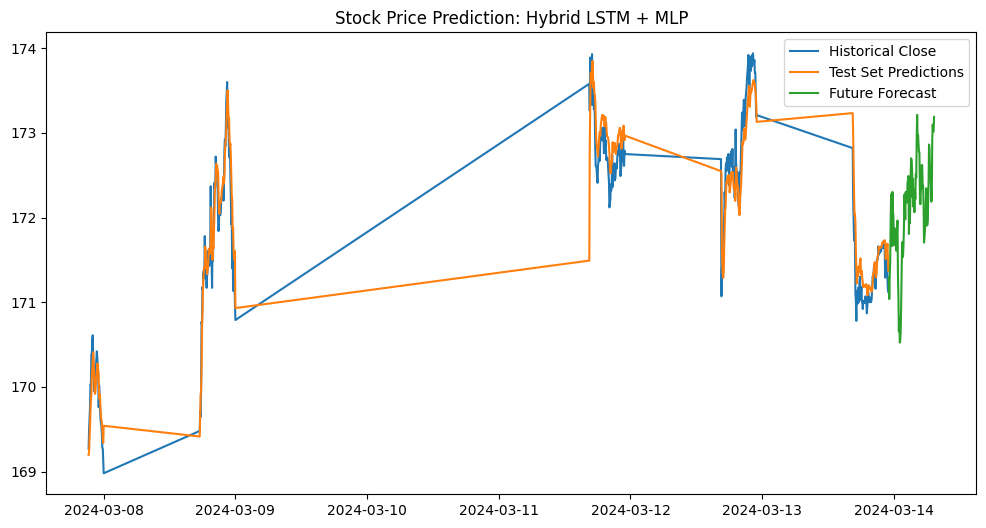

In [22]:
N = 350  # 想显示的最后数据数量

plt.figure(figsize=(12, 6))

# Historical
plt.plot(close_prices.index[-N:], close_prices.values[-N:], label='Historical Close')

# Test predictions
test_index_plot = close_prices.index[seq_length + mlp_train_size : seq_length + mlp_train_size + len(test_preds_actual)]
if len(test_index_plot) == len(test_preds_actual):
    # 同样只显示最后 N 的部分
    plt.plot(test_index_plot[-N:], test_preds_actual[-N:], label='Test Set Predictions')

# Future forecast
plt.plot(forecast_series.index[-N:], forecast_series.values[-N:], label='Future Forecast')

plt.legend()
plt.title("Stock Price Prediction: Hybrid LSTM + MLP")
plt.show()

## Hyperparameter Tuning Overview

### LSTM Tuning

In [23]:
import itertools
import random
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

# Fix random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


lstm_grid = {
    "hidden_size": [32, 50, 64],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.2],
    "lr": [1e-3, 5e-4],
    "batch_size": [32, 64],
    "num_epochs": [8, 12],
}

lstm_keys = list(lstm_grid.keys())
lstm_combos = list(itertools.product(*lstm_grid.values()))

# Shuffle and subsample to keep total compute reasonable
random.shuffle(lstm_combos)
lstm_combos = lstm_combos[:10]   # try up to 10 random combinations

lstm_results = []

# Prepare train/validation split for LSTM (ordered split to avoid leakage)
val_ratio = 0.2
val_size = max(1, int(len(X_train_lstm) * val_ratio))
train_size = len(X_train_lstm) - val_size

train_ds_lstm = TensorDataset(X_train_lstm[:train_size], y_train_lstm[:train_size])
val_ds_lstm = TensorDataset(X_train_lstm[train_size:], y_train_lstm[train_size:])

# Pre-build validation tensors
if len(val_ds_lstm) > 0:
    X_val_lstm = torch.stack([t[0] for t in val_ds_lstm])
    y_val_lstm = torch.stack([t[1] for t in val_ds_lstm])
else:
    X_val_lstm, y_val_lstm = None, None

for combo in lstm_combos:
    params = dict(zip(lstm_keys, combo))
    print(f"\n[Searching LSTM] Testing params: {params}")

    # Initialize LSTM model
    model = LSTMModel(
        input_size=1,
        hidden_size=int(params["hidden_size"]),
        num_layers=int(params["num_layers"]),
        dropout=float(params["dropout"]),
    )

    # Use batch_size from the grid
    batch_size = int(params["batch_size"])
    loader = DataLoader(train_ds_lstm, batch_size=batch_size, shuffle=True)

    # Train the model
    model = train_lstm(
        model,
        loader,
        num_epochs=int(params["num_epochs"]),
        lr=float(params["lr"]),
    )

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        if X_val_lstm is not None:
            preds = model(X_val_lstm).cpu().numpy()

            # Try to inverse-transform back to original price scale
            try:
                preds_actual = scaler_price.inverse_transform(preds)
                y_val_actual = scaler_price.inverse_transform(
                    y_val_lstm.reshape(-1, 1).numpy()
                )
            except Exception:
                preds_actual = preds
                y_val_actual = y_val_lstm.reshape(-1, 1).numpy()

            rmse = np.sqrt(mean_squared_error(y_val_actual, preds_actual))
        else:
            rmse = float("inf")

    print(f"[LSTM] Validation RMSE: {rmse:.4f}")
    lstm_results.append((rmse, params, model))

# Rank LSTM candidates
lstm_results.sort(key=lambda x: x[0])

print("\n===== Top 3 LSTM Candidates =====")
for r in lstm_results[:3]:
    print(f"RMSE: {r[0]:.4f} | Params: {r[1]}")

if lstm_results:
    best_lstm_rmse, best_lstm_params, best_lstm_model = lstm_results[0]
    print(f"\n[Best LSTM] RMSE: {best_lstm_rmse:.4f} | Params: {best_lstm_params}")



[Searching LSTM] Testing params: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 32, 'num_epochs': 8}
Starting LSTM training...
LSTM Training completed.
[LSTM] Validation RMSE: 0.3900

[Searching LSTM] Testing params: {'hidden_size': 50, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'num_epochs': 12}
Starting LSTM training...
LSTM Epoch [10/12], Loss: 0.00033102
LSTM Training completed.
[LSTM] Validation RMSE: 0.7074

[Searching LSTM] Testing params: {'hidden_size': 50, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64, 'num_epochs': 8}
Starting LSTM training...
LSTM Training completed.
[LSTM] Validation RMSE: 0.8237

[Searching LSTM] Testing params: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
Starting LSTM training...


c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


LSTM Epoch [10/12], Loss: 0.00003344
LSTM Training completed.
[LSTM] Validation RMSE: 0.3416

[Searching LSTM] Testing params: {'hidden_size': 50, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
Starting LSTM training...
LSTM Epoch [10/12], Loss: 0.00002522
LSTM Training completed.
[LSTM] Validation RMSE: 0.3603

[Searching LSTM] Testing params: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'num_epochs': 8}
Starting LSTM training...
LSTM Training completed.
[LSTM] Validation RMSE: 0.8717

[Searching LSTM] Testing params: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
Starting LSTM training...
LSTM Epoch [10/12], Loss: 0.00004697
LSTM Training completed.
[LSTM] Validation RMSE: 0.3422

[Searching LSTM] Testing params: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 32, 'num_epochs': 8}
Starting LSTM training...
LSTM Training comp

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


LSTM Epoch [10/12], Loss: 0.00005656
LSTM Training completed.
[LSTM] Validation RMSE: 0.4688

[Searching LSTM] Testing params: {'hidden_size': 50, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'num_epochs': 8}
Starting LSTM training...
LSTM Training completed.
[LSTM] Validation RMSE: 0.7298

===== Top 3 LSTM Candidates =====
RMSE: 0.3416 | Params: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
RMSE: 0.3422 | Params: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
RMSE: 0.3603 | Params: {'hidden_size': 50, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}

[Best LSTM] RMSE: 0.3416 | Params: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}


### MLP Tuning

In [24]:
mlp_grid = {
    "hidden_size1": [32, 64, 128],
    "hidden_size2": [16, 32],
    "lr": [1e-3, 5e-4],
    "batch_size": [32, 64],
    "num_epochs": [8, 12],
}

mlp_keys = list(mlp_grid.keys())
mlp_combos = list(itertools.product(*mlp_grid.values()))
random.shuffle(mlp_combos)
mlp_combos = mlp_combos[:10]   # limit to at most 10 combinations

mlp_results = []

# Train/validation split for MLP
val_size_mlp = max(1, int(len(X_train_mlp) * 0.2))
train_size_mlp = len(X_train_mlp) - val_size_mlp

train_ds_mlp = TensorDataset(X_train_mlp[:train_size_mlp], y_train_mlp[:train_size_mlp])
val_ds_mlp = TensorDataset(X_train_mlp[train_size_mlp:], y_train_mlp[train_size_mlp:])

if len(val_ds_mlp) > 0:
    X_val_mlp = torch.stack([t[0] for t in val_ds_mlp])
    y_val_mlp = torch.stack([t[1] for t in val_ds_mlp])
else:
    X_val_mlp, y_val_mlp = None, None

for combo in mlp_combos:
    params = dict(zip(mlp_keys, combo))
    print(f"\n[Searching MLP] Testing params: {params}")

    model_mlp = MLPModel(
        input_size=mlp_input_size,
        hidden_size1=int(params["hidden_size1"]),
        hidden_size2=int(params["hidden_size2"]),
    )

    batch_size = int(params["batch_size"])
    loader_mlp = DataLoader(train_ds_mlp, batch_size=batch_size, shuffle=True)

    # Train MLP
    model_mlp = train_mlp(
        model_mlp,
        loader_mlp,
        num_epochs=int(params["num_epochs"]),
        lr=float(params["lr"]),
    )

    # Evaluate on validation set
    model_mlp.eval()
    with torch.no_grad():
        if X_val_mlp is not None:
            preds = model_mlp(X_val_mlp).cpu().numpy()

            try:
                preds_actual = scaler_price.inverse_transform(preds)
                y_val_actual = scaler_price.inverse_transform(
                    y_val_mlp.reshape(-1, 1).numpy()
                )
            except Exception:
                preds_actual = preds
                y_val_actual = y_val_mlp.reshape(-1, 1).numpy()

            rmse = np.sqrt(mean_squared_error(y_val_actual, preds_actual))
        else:
            rmse = float("inf")

    print(f"[MLP] Validation RMSE: {rmse:.4f}")
    mlp_results.append((rmse, params, model_mlp))

# Rank MLP candidates
mlp_results.sort(key=lambda x: x[0])
print("\n===== Top 3 MLP Candidates =====")
for r in mlp_results[:3]:
    print(f"RMSE: {r[0]:.4f} | Params: {r[1]}")

if mlp_results:
    best_mlp_rmse, best_mlp_params, best_mlp_model = mlp_results[0]
    print(f"\n[Best MLP] RMSE: {best_mlp_rmse:.4f} | Params: {best_mlp_params}")




[Searching MLP] Testing params: {'hidden_size1': 64, 'hidden_size2': 16, 'lr': 0.0005, 'batch_size': 64, 'num_epochs': 8}
Starting MLP training...
MLP Training completed.
[MLP] Validation RMSE: 2.0783

[Searching MLP] Testing params: {'hidden_size1': 64, 'hidden_size2': 16, 'lr': 0.001, 'batch_size': 64, 'num_epochs': 8}
Starting MLP training...
MLP Training completed.
[MLP] Validation RMSE: 2.2478

[Searching MLP] Testing params: {'hidden_size1': 32, 'hidden_size2': 32, 'lr': 0.001, 'batch_size': 64, 'num_epochs': 8}
Starting MLP training...
MLP Training completed.
[MLP] Validation RMSE: 2.8152

[Searching MLP] Testing params: {'hidden_size1': 32, 'hidden_size2': 32, 'lr': 0.0005, 'batch_size': 64, 'num_epochs': 8}
Starting MLP training...
MLP Training completed.
[MLP] Validation RMSE: 2.2122

[Searching MLP] Testing params: {'hidden_size1': 64, 'hidden_size2': 16, 'lr': 0.001, 'batch_size': 32, 'num_epochs': 12}
Starting MLP training...
MLP Epoch [10/12], Loss: 0.00003304
MLP Traini

In [25]:
import itertools
import random
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# -----------------------------
# 1) Define search spaces
# -----------------------------
lstm_grid = {
    "hidden_size":  [32, 64, 96],
    "num_layers":   [1, 2],
    "dropout":      [0.0, 0.2, 0.3],
    "lr":           [1e-3, 5e-4],
    "batch_size":   [32, 64],
    "num_epochs":   [10, 15],
}

mlp_grid = {
    "hidden_size1": [64, 128, 256],
    "hidden_size2": [32, 64],
    "lr":           [1e-3, 5e-4],
    "batch_size":   [32, 64],
    "num_epochs":   [10, 15],
}

# Build joint parameter space for random search
lstm_keys = list(lstm_grid.keys())
mlp_keys = list(mlp_grid.keys())

lstm_combos = list(itertools.product(*lstm_grid.values()))
mlp_combos  = list(itertools.product(*mlp_grid.values()))

joint_param_list = []
for lstm_vals in lstm_combos:
    for mlp_vals in mlp_combos:
        param_dict = {}

        # Prefix to distinguish LSTM vs MLP params
        for k, v in zip(lstm_keys, lstm_vals):
            param_dict[f"lstm_{k}"] = v
        for k, v in zip(mlp_keys, mlp_vals):
            param_dict[f"mlp_{k}"] = v

        joint_param_list.append(param_dict)

# Shuffle and subsample to keep total compute reasonable
random.shuffle(joint_param_list)
max_trials = 20   # you can increase this if you have more compute
joint_param_list = joint_param_list[:max_trials]

print(f"Total joint candidates to evaluate: {len(joint_param_list)}")

# -----------------------------
# 2) Prepare base LSTM dataset
# -----------------------------
# We already have X_train_lstm, y_train_lstm from previous preprocessing cell.
lstm_train_ds = TensorDataset(X_train_lstm, y_train_lstm)

# Container for results
hybrid_results = []

# -----------------------------
# 3) Joint search loop
# -----------------------------
for trial_idx, params in enumerate(joint_param_list, start=1):
    print("\n" + "=" * 80)
    print(f"[Trial {trial_idx}/{len(joint_param_list)}] Testing joint params:")
    print(params)

    # -------------------------
    # 3.1 Train LSTM with current hyperparameters
    # -------------------------
    lstm_hidden_size = int(params["lstm_hidden_size"])
    lstm_num_layers  = int(params["lstm_num_layers"])
    lstm_dropout     = float(params["lstm_dropout"])
    lstm_lr          = float(params["lstm_lr"])
    lstm_batch_size  = int(params["lstm_batch_size"])
    lstm_epochs      = int(params["lstm_num_epochs"])

    # Build DataLoader for LSTM
    lstm_loader = DataLoader(
        lstm_train_ds,
        batch_size=lstm_batch_size,
        shuffle=True
    )

    # Initialize LSTM model
    model_lstm = LSTMModel(
        input_size=1,
        hidden_size=lstm_hidden_size,
        num_layers=lstm_num_layers,
        dropout=lstm_dropout,
    )

    # Train LSTM
    model_lstm = train_lstm(
        model_lstm,
        lstm_loader,
        num_epochs=lstm_epochs,
        lr=lstm_lr,
    )

    # -------------------------
    # 3.2 Build MLP dataset using current LSTM (full history)
    # -------------------------
    model_lstm.eval()
    with torch.no_grad():
        # X_lstm should be the full sequence input (shape: [N_samples, seq_len, 1])
        all_lstm_inputs = torch.tensor(X_lstm, dtype=torch.float32)
        lstm_outputs = model_lstm(all_lstm_inputs)  # shape: [N_samples, 1]

    # Align exogenous features
    aligned_exog = scaled_exog[seq_length:]  # same logic as your previous cell

    # Ensure all arrays have the same length
    max_target_len = len(scaled_close) - seq_length
    min_len = min(len(lstm_outputs), len(aligned_exog), max_target_len)

    lstm_features = lstm_outputs[:min_len].detach().cpu().numpy()  # (min_len, 1)
    exog_features = aligned_exog[:min_len]                         # (min_len, d_exog)

    # Hybrid inputs for MLP: [LSTM_pred, exog...]
    X_mlp_all = np.hstack([lstm_features, exog_features]).astype(np.float32)
    y_mlp_all = scaled_close[seq_length:seq_length + min_len].astype(np.float32)

    # -------------------------
    # 3.3 Time-based train / test split for MLP
    # -------------------------
    # Use the same index as for LSTM train/test, but clipped to min_len
    mlp_train_size = min(train_split_idx, min_len)
    if mlp_train_size <= 2:
        print("Not enough data for MLP training, skipping this trial.")
        continue

    X_train_mlp_all = torch.tensor(X_mlp_all[:mlp_train_size], dtype=torch.float32)
    y_train_mlp_all = torch.tensor(y_mlp_all[:mlp_train_size], dtype=torch.float32)

    # Remaining part X_mlp_all[mlp_train_size:] can be reserved for final test (not used here)

    # -------------------------
    # 3.4 Inside-train validation split for hyperparameter selection
    # -------------------------
    val_ratio = 0.2
    val_size = max(1, int(len(X_train_mlp_all) * val_ratio))
    train_size = len(X_train_mlp_all) - val_size

    if train_size <= 0:
        print("Not enough data after train/val split, skipping this trial.")
        continue

    X_train_mlp = X_train_mlp_all[:train_size]
    y_train_mlp = y_train_mlp_all[:train_size]
    X_val_mlp   = X_train_mlp_all[train_size:]
    y_val_mlp   = y_train_mlp_all[train_size:]

    train_ds_mlp = TensorDataset(X_train_mlp, y_train_mlp)

    # -------------------------
    # 3.5 Train MLP with current hyperparameters
    # -------------------------
    mlp_input_size = X_mlp_all.shape[1]
    mlp_hidden_size1 = int(params["mlp_hidden_size1"])
    mlp_hidden_size2 = int(params["mlp_hidden_size2"])
    mlp_lr           = float(params["mlp_lr"])
    mlp_batch_size   = int(params["mlp_batch_size"])
    mlp_epochs       = int(params["mlp_num_epochs"])

    model_mlp = MLPModel(
        input_size=mlp_input_size,
        hidden_size1=mlp_hidden_size1,
        hidden_size2=mlp_hidden_size2,
    )

    loader_mlp = DataLoader(
        train_ds_mlp,
        batch_size=mlp_batch_size,
        shuffle=True,
    )

    model_mlp = train_mlp(
        model_mlp,
        loader_mlp,
        num_epochs=mlp_epochs,
        lr=mlp_lr,
    )

    # -------------------------
    # 3.6 Evaluate on validation set (hybrid performance)
    # -------------------------
    model_mlp.eval()
    with torch.no_grad():
        val_pred_scaled = model_mlp(X_val_mlp).cpu().numpy()

    val_true_scaled = y_val_mlp.reshape(-1, 1).cpu().numpy()

    # Map back to original price scale for RMSE
    try:
        val_pred = scaler_price.inverse_transform(val_pred_scaled)
        val_true = scaler_price.inverse_transform(val_true_scaled)
    except Exception:
        # Fallback if scaler has issues
        val_pred = val_pred_scaled
        val_true = val_true_scaled

    mse = mean_squared_error(val_true, val_pred)
    rmse = np.sqrt(mse)

    print(f"[Hybrid] Validation RMSE: {rmse:.4f}")

    # Store results
    hybrid_results.append((rmse, params, model_lstm, model_mlp))

# -----------------------------
# 4) Rank and select best combination
# -----------------------------
if not hybrid_results:
    print("No valid hybrid trial was completed. Please check data shapes and splits.")
else:
    # Sort by RMSE ascending
    hybrid_results.sort(key=lambda x: x[0])

    print("\n===== Top 3 Hybrid Candidates (by validation RMSE) =====")
    top_k = min(3, len(hybrid_results))
    for i in range(top_k):
        rmse_i, params_i, _, _ = hybrid_results[i]
        print(f"Rank {i+1}: RMSE={rmse_i:.4f} | Params={params_i}")

    best_rmse, best_params, best_lstm_model, best_mlp_model = hybrid_results[0]
    print("\n===== Best Hybrid Model =====")
    print(f"Best RMSE={best_rmse:.4f}")
    print(f"Best Params={best_params}")

    # Expose best models for later forecasting
    lstm_model = best_lstm_model
    mlp_model  = best_mlp_model


Total joint candidates to evaluate: 20

[Trial 1/20] Testing joint params:
{'lstm_hidden_size': 96, 'lstm_num_layers': 2, 'lstm_dropout': 0.3, 'lstm_lr': 0.001, 'lstm_batch_size': 64, 'lstm_num_epochs': 15, 'mlp_hidden_size1': 64, 'mlp_hidden_size2': 64, 'mlp_lr': 0.0005, 'mlp_batch_size': 64, 'mlp_num_epochs': 10}
Starting LSTM training...
LSTM Epoch [10/15], Loss: 0.00013543
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/10], Loss: 0.00009452
MLP Training completed.
[Hybrid] Validation RMSE: 2.0459

[Trial 2/20] Testing joint params:
{'lstm_hidden_size': 32, 'lstm_num_layers': 1, 'lstm_dropout': 0.3, 'lstm_lr': 0.001, 'lstm_batch_size': 64, 'lstm_num_epochs': 10, 'mlp_hidden_size1': 64, 'mlp_hidden_size2': 64, 'mlp_lr': 0.001, 'mlp_batch_size': 64, 'mlp_num_epochs': 15}
Starting LSTM training...


c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


LSTM Epoch [10/10], Loss: 0.00002613
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/15], Loss: 0.00006689
MLP Training completed.
[Hybrid] Validation RMSE: 3.4631

[Trial 3/20] Testing joint params:
{'lstm_hidden_size': 32, 'lstm_num_layers': 1, 'lstm_dropout': 0.0, 'lstm_lr': 0.0005, 'lstm_batch_size': 64, 'lstm_num_epochs': 10, 'mlp_hidden_size1': 256, 'mlp_hidden_size2': 32, 'mlp_lr': 0.0005, 'mlp_batch_size': 64, 'mlp_num_epochs': 15}
Starting LSTM training...
LSTM Epoch [10/10], Loss: 0.00003922
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/15], Loss: 0.00006443
MLP Training completed.
[Hybrid] Validation RMSE: 1.7110

[Trial 4/20] Testing joint params:
{'lstm_hidden_size': 32, 'lstm_num_layers': 2, 'lstm_dropout': 0.3, 'lstm_lr': 0.0005, 'lstm_batch_size': 64, 'lstm_num_epochs': 10, 'mlp_hidden_size1': 128, 'mlp_hidden_size2': 64, 'mlp_lr': 0.001, 'mlp_batch_size': 32, 'mlp_num_epochs': 15}
Starting LSTM training...
LSTM Epoch [10/10], Loss: 0.0

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


LSTM Epoch [10/10], Loss: 0.00001904
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/10], Loss: 0.00002076
MLP Training completed.
[Hybrid] Validation RMSE: 1.6472

[Trial 14/20] Testing joint params:
{'lstm_hidden_size': 64, 'lstm_num_layers': 2, 'lstm_dropout': 0.3, 'lstm_lr': 0.0005, 'lstm_batch_size': 64, 'lstm_num_epochs': 10, 'mlp_hidden_size1': 256, 'mlp_hidden_size2': 32, 'mlp_lr': 0.001, 'mlp_batch_size': 64, 'mlp_num_epochs': 10}
Starting LSTM training...
LSTM Epoch [10/10], Loss: 0.00053132
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/10], Loss: 0.00009424
MLP Training completed.
[Hybrid] Validation RMSE: 2.7830

[Trial 15/20] Testing joint params:
{'lstm_hidden_size': 32, 'lstm_num_layers': 2, 'lstm_dropout': 0.3, 'lstm_lr': 0.001, 'lstm_batch_size': 64, 'lstm_num_epochs': 15, 'mlp_hidden_size1': 64, 'mlp_hidden_size2': 64, 'mlp_lr': 0.0005, 'mlp_batch_size': 64, 'mlp_num_epochs': 15}
Starting LSTM training...
LSTM Epoch [10/15], Loss: 0.0

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


LSTM Epoch [10/10], Loss: 0.00005972
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/15], Loss: 0.00012378
MLP Training completed.
[Hybrid] Validation RMSE: 1.8424

[Trial 18/20] Testing joint params:
{'lstm_hidden_size': 96, 'lstm_num_layers': 1, 'lstm_dropout': 0.2, 'lstm_lr': 0.001, 'lstm_batch_size': 64, 'lstm_num_epochs': 15, 'mlp_hidden_size1': 128, 'mlp_hidden_size2': 32, 'mlp_lr': 0.001, 'mlp_batch_size': 64, 'mlp_num_epochs': 10}
Starting LSTM training...


c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


LSTM Epoch [10/15], Loss: 0.00002600
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/10], Loss: 0.00009695
MLP Training completed.
[Hybrid] Validation RMSE: 2.1456

[Trial 19/20] Testing joint params:
{'lstm_hidden_size': 64, 'lstm_num_layers': 2, 'lstm_dropout': 0.0, 'lstm_lr': 0.001, 'lstm_batch_size': 64, 'lstm_num_epochs': 15, 'mlp_hidden_size1': 64, 'mlp_hidden_size2': 32, 'mlp_lr': 0.0005, 'mlp_batch_size': 64, 'mlp_num_epochs': 15}
Starting LSTM training...
LSTM Epoch [10/15], Loss: 0.00003429
LSTM Training completed.
Starting MLP training...
MLP Epoch [10/15], Loss: 0.00024219
MLP Training completed.
[Hybrid] Validation RMSE: 3.7769

[Trial 20/20] Testing joint params:
{'lstm_hidden_size': 96, 'lstm_num_layers': 1, 'lstm_dropout': 0.0, 'lstm_lr': 0.0005, 'lstm_batch_size': 64, 'lstm_num_epochs': 15, 'mlp_hidden_size1': 128, 'mlp_hidden_size2': 64, 'mlp_lr': 0.0005, 'mlp_batch_size': 32, 'mlp_num_epochs': 10}
Starting LSTM training...
LSTM Epoch [10/15], Loss: 0.

Total length: 101860, train: 81488, test/forecast: 20372
Hybrid test RMSE (original price scale): 36.9747


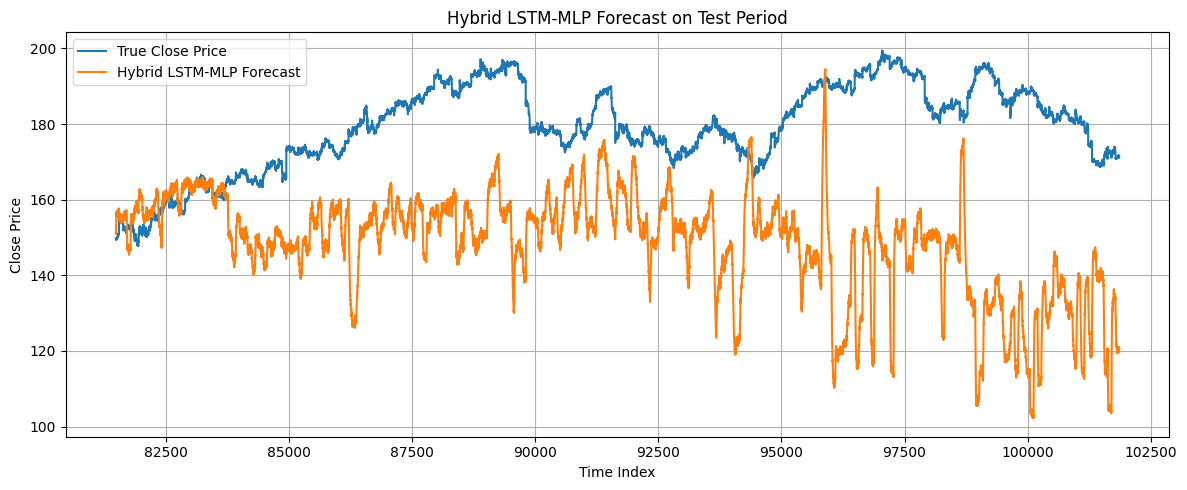

In [26]:
# ----------------------------------
# 1) Define hybrid forecast function
# ----------------------------------
def run_hybrid_forecast(
    lstm_model,
    mlp_model,
    scaled_close,
    scaled_exog,
    scaler_price,
    seq_length,
    train_end_idx,
    forecast_steps,
    noise_level=0.0,
):
    """
    Multi-step hybrid forecast using LSTM + MLP.

    lstm_model: trained LSTMModel
    mlp_model: trained MLPModel
    scaled_close: 1D numpy array of scaled close prices
    scaled_exog: 2D numpy array of scaled exogenous features
    scaler_price: fitted scaler for close prices
    seq_length: length of LSTM input window
    train_end_idx: index where training data ends (exclusive)
    forecast_steps: number of steps to forecast ahead
    noise_level: std of Gaussian noise added in scaled space (optional)
    """

    lstm_model.eval()
    mlp_model.eval()

    # Initial window: last seq_length points from training part
    if train_end_idx <= seq_length:
        raise ValueError("train_end_idx must be larger than seq_length.")

    # shape: (seq_length,)
    history_window = scaled_close[train_end_idx - seq_length : train_end_idx].copy()

    # Prepare containers
    preds_scaled_list = []

    # Exogenous features for the test range
    exog_future = scaled_exog[train_end_idx : train_end_idx + forecast_steps]

    for step in range(forecast_steps):
        # 1) Prepare LSTM input: last seq_length points
        lstm_input_np = history_window[-seq_length:].reshape(1, seq_length, 1)
        lstm_input = torch.tensor(lstm_input_np, dtype=torch.float32)

        with torch.no_grad():
            lstm_out = lstm_model(lstm_input)    # shape: (1, 1)
        lstm_pred_scaled = lstm_out.numpy()     # (1, 1)

        # 2) Build MLP input: [lstm_pred, exog_t]
        exog_t = exog_future[step].reshape(1, -1)      # (1, d_exog)
        mlp_input_np = np.hstack([lstm_pred_scaled, exog_t]).astype(np.float32)
        mlp_input = torch.tensor(mlp_input_np, dtype=torch.float32)

        with torch.no_grad():
            mlp_pred_scaled = mlp_model(mlp_input).numpy()  # (1, 1)

        # 3) Optionally add noise in scaled space
        if noise_level > 0.0:
            mlp_pred_scaled += np.random.normal(0.0, noise_level, size=mlp_pred_scaled.shape)

        # 4) Append prediction and update history window
        preds_scaled_list.append(mlp_pred_scaled.item())
        # Update history with predicted close
        history_window = np.append(history_window, mlp_pred_scaled.item())

    # Convert list to array, shape (forecast_steps, 1)
    preds_scaled = np.array(preds_scaled_list).reshape(-1, 1)

    # Inverse transform to original price scale
    preds = scaler_price.inverse_transform(preds_scaled).reshape(-1)

    return preds


# ----------------------------------
# 2) Set train/test split and forecast length
# ----------------------------------
# 80% for training (same logic as before)
n_total = len(close_prices)
raw_train_size = int(n_total * 0.8)

# Forecast exactly over the held-out test period
forecast_steps = n_total - raw_train_size
print(f"Total length: {n_total}, train: {raw_train_size}, test/forecast: {forecast_steps}")

# ----------------------------------
# 3) Run hybrid forecast using best tuned models
# ----------------------------------
hybrid_forecast = run_hybrid_forecast(
    lstm_model=lstm_model,
    mlp_model=mlp_model,
    scaled_close=scaled_close,
    scaled_exog=scaled_exog,
    scaler_price=scaler_price,
    seq_length=seq_length,
    train_end_idx=raw_train_size,
    forecast_steps=forecast_steps,
    noise_level=0.01,   # you can tune this; 0.0 means no noise
)

# Ground truth for the test range (original price scale)
test_true = close_prices[raw_train_size : raw_train_size + forecast_steps]
test_index = np.arange(raw_train_size, raw_train_size + forecast_steps)

# ----------------------------------
# 4) Evaluate test RMSE
# ----------------------------------
mse_test = mean_squared_error(test_true, hybrid_forecast)
rmse_test = np.sqrt(mse_test)
print(f"Hybrid test RMSE (original price scale): {rmse_test:.4f}")

# ----------------------------------
# 5) Plot true vs forecasted prices
# ----------------------------------
plt.figure(figsize=(12, 5))
plt.plot(test_index, test_true, label="True Close Price")
plt.plot(test_index, hybrid_forecast, label="Hybrid LSTM-MLP Forecast")
plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.title("Hybrid LSTM-MLP Forecast on Test Period")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
